In [21]:
%matplotlib widget

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
spectrum_1 = pd.read_csv("Spectrum1s_1_noreg_gas_exp.csv")
spectrum_2 = pd.read_csv("Spectrum1s_2_noreg_gas_exp.csv")
spectrum_3 = pd.read_csv("Spectrum1s_3_noreg_gas_exp.csv")

In [24]:
spectrum_2

,Name,Flux,Error_flux
0,Hgamma,0.175898,0.040812
1,Hbeta,0.555240,0.039070
2,Halpha,3.335496,0.042907
3,[SII]6716,0.275117,0.022022
4,[SII]6731,0.233165,0.020583
5,HeII4687,0.000000,0.028994
6,HeI5876,0.090107,0.023363
7,[OIII]4959,0.035166,0.033353
8,[OIII]5007,0.105499,0.033353
9,[OI]6300,0.000000,0.015143


In [25]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

0.09000154358873312
0.05775636878255195
0.06664683658499679
0.14066068038644336
0.017970672975580363
0.035209491944021974
0.06219593857656062
0.018698451820383367
0.018778216211563354


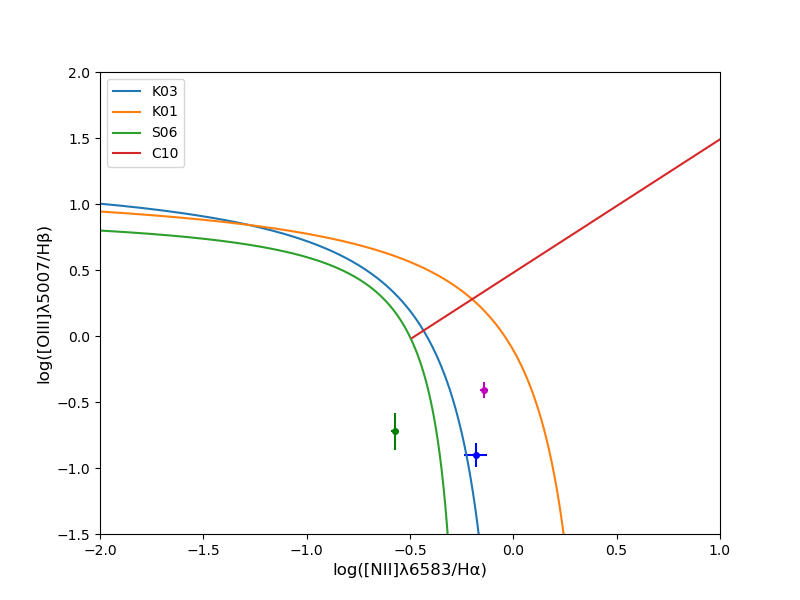

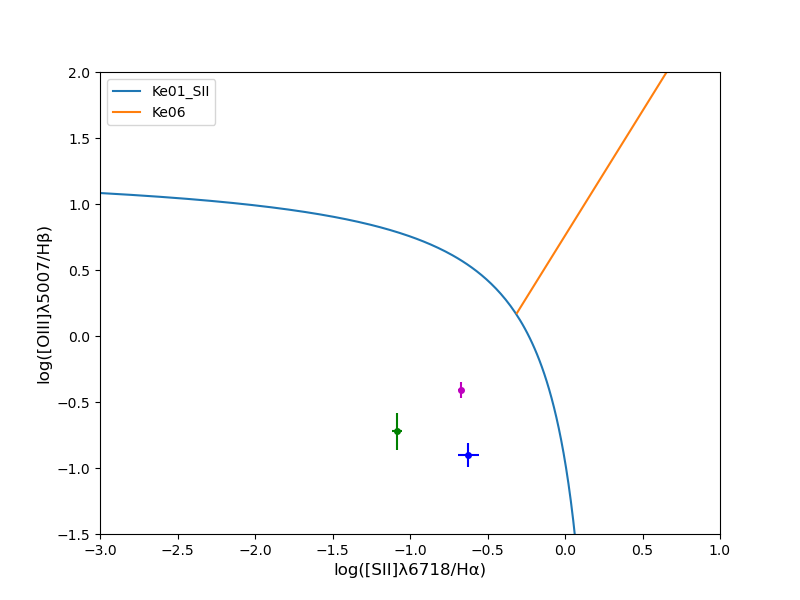

In [26]:
plt.figure(figsize=(8,6))

OIII_HB_1 = spectrum_1['Flux'][8]/spectrum_1['Flux'][1]
NII_HA_1 = spectrum_1['Flux'][12]/spectrum_1['Flux'][2]
SII_HA_1 = spectrum_1['Flux'][3]/spectrum_1['Flux'][2]
err_OIII_HB_1 = error_ratio(spectrum_1['Error_flux'][8], spectrum_1['Error_flux'][1], spectrum_1['Flux'][8], spectrum_1['Flux'][1])
err_NII_HA_1 = error_ratio(spectrum_1['Error_flux'][12], spectrum_1['Error_flux'][2], spectrum_1['Flux'][12], spectrum_1['Flux'][2])
err_SII_HA_1 = error_ratio(spectrum_1['Error_flux'][3], spectrum_1['Error_flux'][2], spectrum_1['Flux'][3], spectrum_1['Flux'][2])

OIII_HB_2 = spectrum_2['Flux'][8]/spectrum_2['Flux'][1]
NII_HA_2 = spectrum_2['Flux'][12]/spectrum_2['Flux'][2]
SII_HA_2 = spectrum_2['Flux'][3]/spectrum_2['Flux'][2]
err_OIII_HB_2 = error_ratio(spectrum_2['Error_flux'][8], spectrum_2['Error_flux'][1], spectrum_2['Flux'][8], spectrum_2['Flux'][1])
err_NII_HA_2 = error_ratio(spectrum_2['Error_flux'][12], spectrum_2['Error_flux'][2], spectrum_2['Flux'][12], spectrum_2['Flux'][2])
err_SII_HA_2 = error_ratio(spectrum_2['Error_flux'][3], spectrum_2['Error_flux'][2], spectrum_2['Flux'][3], spectrum_2['Flux'][2])

OIII_HB_3 = spectrum_3['Flux'][8]/spectrum_3['Flux'][1]
NII_HA_3 = spectrum_3['Flux'][12]/spectrum_3['Flux'][2]
SII_HA_3 = spectrum_3['Flux'][3]/spectrum_3['Flux'][2]
err_OIII_HB_3 = error_ratio(spectrum_3['Error_flux'][8], spectrum_3['Error_flux'][1], spectrum_3['Flux'][8], spectrum_3['Flux'][1])
err_NII_HA_3 = error_ratio(spectrum_3['Error_flux'][12], spectrum_3['Error_flux'][2], spectrum_3['Flux'][12], spectrum_3['Flux'][2])
err_SII_HA_3 = error_ratio(spectrum_3['Error_flux'][3], spectrum_3['Error_flux'][2], spectrum_3['Flux'][3], spectrum_3['Flux'][2])

plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'K03')
plt.plot(x1, Ke01(x1), label = 'K01')
plt.plot(x2, S06(x2), label = 'S06')
plt.plot(x3, C10(x3), label = 'C10')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')

x = np.linspace(-3, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01_SII')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-3, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s', bbox_inches='tight')

## BPT con correzioni

In [27]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Contaminations/Areas_OIII_1s.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Contaminations/Areas_NII_1s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Contaminations/Areas_SII_1s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Contaminations/Areas_Halpha_1s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Contaminations/Areas_Hbeta_1s.csv",
                        index_col = 0)

In [28]:
areas_SII

,Peak 1,Peak 2,Peak 3
Blue,99.753,53.275,0.406
Green,0.076,37.935,0.039
Purple,0.171,8.790,99.555


In [29]:
areas_SII['Peak 1'].iloc[0]

99.753

In [30]:
def true_flux(spectrum, spectrum2, spectrum3, area, e_1, e_2, e_3):
    riga_1 = spectrum*area['Peak 1'].iloc[0]/100
    err_1 = e_1*area['Peak 1'].iloc[0]/100
    riga_2 = spectrum2*area['Peak 2'].iloc[1]/100
    err_2 = e_2*area['Peak 2'].iloc[1]/100
    riga_3 = spectrum3*area['Peak 3'].iloc[2]/100
    err_3 = e_3*area['Peak 3'].iloc[2]/100
   # riga_4 = spectrum4*area['Peak 4'].iloc[3]/100
   # err_4 = e_4*area['Peak 4'].iloc[3]/100
    return riga_1, riga_2, riga_3, err_1, err_2, err_3 #, err_4

In [31]:
OIII_1, OIII_2, OIII_3, err_OIII_1, err_OIII_2, err_OIII_3 = true_flux(spectrum_1['Flux'][8], spectrum_2['Flux'][8], 
                                                                                           spectrum_3['Flux'][8], areas_OIII,
                                                                                          spectrum_1['Error_flux'][8], spectrum_2['Error_flux'][8], 
                                                                                           spectrum_3['Error_flux'][8])
HB_1, HB_2, HB_3, err_HB_1, err_HB_2, err_HB_3 = true_flux(spectrum_1['Flux'][1], spectrum_2['Flux'][1], 
                                                                           spectrum_3['Flux'][1], areas_Hbeta,
                                                                           spectrum_1['Error_flux'][1], spectrum_2['Error_flux'][1], 
                                                                            spectrum_3['Error_flux'][1])
HA_1, HA_2, HA_3, err_HA_1, err_HA_2, err_HA_3 = true_flux(spectrum_1['Flux'][2], spectrum_2['Flux'][2],
                                                                           spectrum_3['Flux'][2], areas_Halpha,
                                                                           spectrum_1['Error_flux'][2], spectrum_2['Error_flux'][2], 
                                                                            spectrum_3['Error_flux'][2])
NII_1, NII_2, NII_3, err_NII_1, err_NII_2, err_NII_3 = true_flux(spectrum_1['Flux'][12], spectrum_2['Flux'][12],
                                                                                   spectrum_3['Flux'][12], areas_NII,
                                                                                   spectrum_1['Error_flux'][12], spectrum_2['Error_flux'][12], 
                                                                                   spectrum_3['Error_flux'][12])
SII_1, SII_2, SII_3, err_SII_1, err_SII_2, err_SII_3 = true_flux(spectrum_1['Flux'][3], spectrum_2['Flux'][3], 
                                                                                   spectrum_3['Flux'][3], areas_SII,
                                                                                   spectrum_1['Error_flux'][3], spectrum_2['Error_flux'][3], 
                                                                                   spectrum_3['Error_flux'][3])

0.09000154358873313
0.05775636878255194
0.06664683658499677
0.14066068038644336
0.017970672975580363
0.035209491944021974
0.062195938576560625
0.018698451820383367
0.01877821621156335


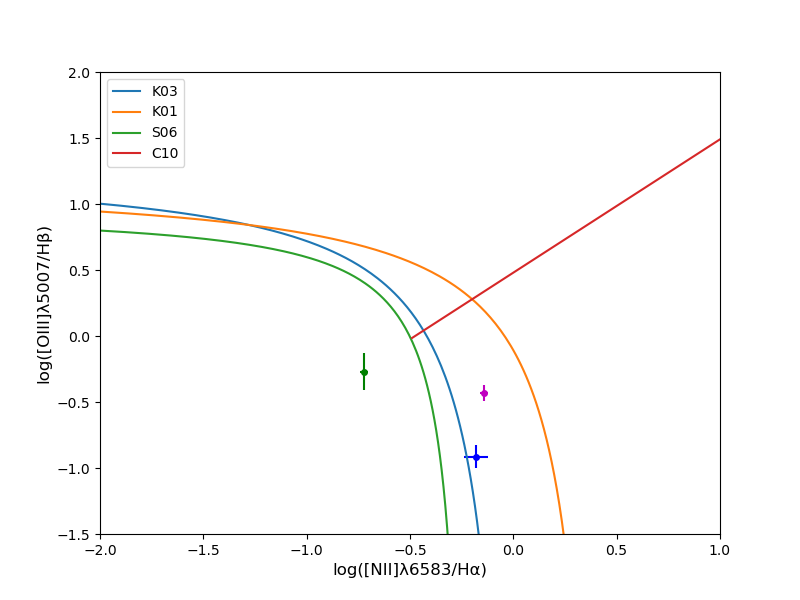

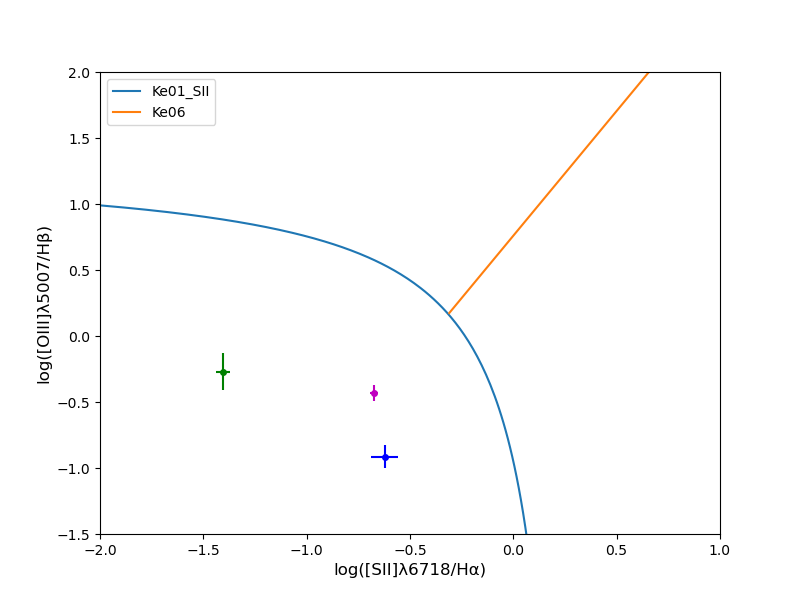

In [32]:
 plt.figure(figsize=(8,6))

OIII_HB_1_true = OIII_1/HB_1
NII_HA_1_true = NII_1/HA_1
SII_HA_1_true = SII_1/HA_1
err_OIII_HB_1_true = error_ratio(err_OIII_1, err_HB_1, OIII_1, HB_1)
err_NII_HA_1_true = error_ratio(err_NII_1, err_HA_1, NII_1, HA_1)
err_SII_HA_1_true = error_ratio(err_SII_1, err_HA_1, SII_1, HA_1)

OIII_HB_2_true = OIII_2/HB_2
NII_HA_2_true = NII_2/HA_2
SII_HA_2_true = SII_2/HA_2
err_OIII_HB_2_true = error_ratio(err_OIII_2, err_HB_2, OIII_2, HB_2)
err_NII_HA_2_true = error_ratio(err_NII_2, err_HA_2, NII_2, HA_2)
err_SII_HA_2_true = error_ratio(err_SII_2, err_HA_2, SII_2, HA_2)

OIII_HB_3_true = OIII_3/HB_3
NII_HA_3_true = NII_3/HA_3
SII_HA_3_true = SII_3/HA_3
err_OIII_HB_3_true = error_ratio(err_OIII_3, err_HB_3, OIII_3, HB_3)
err_NII_HA_3_true = error_ratio(err_NII_3, err_HA_3, NII_3, HA_3)
err_SII_HA_3_true = error_ratio(err_SII_3, err_HA_3, SII_3, HA_3)

plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'K03')
plt.plot(x1, Ke01(x1), label = 'K01')
plt.plot(x2, S06(x2), label = 'S06')
plt.plot(x3, C10(x3), label = 'C10')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01_SII')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s_true', bbox_inches='tight')

In [33]:
np.log10(SII_HA_1_true)

-0.6231082639467121

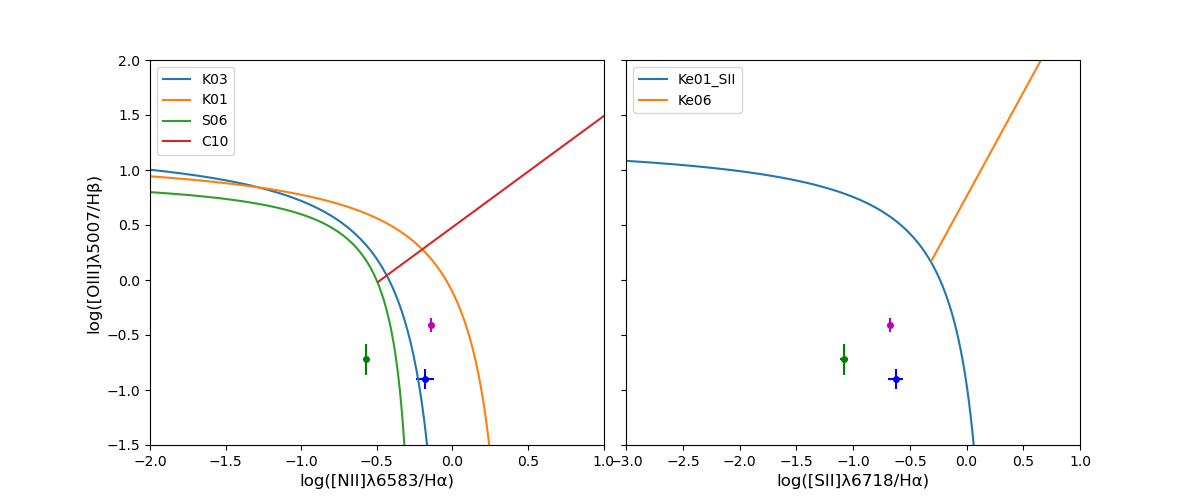

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-3, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-3, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both.png', bbox_inches='tight')

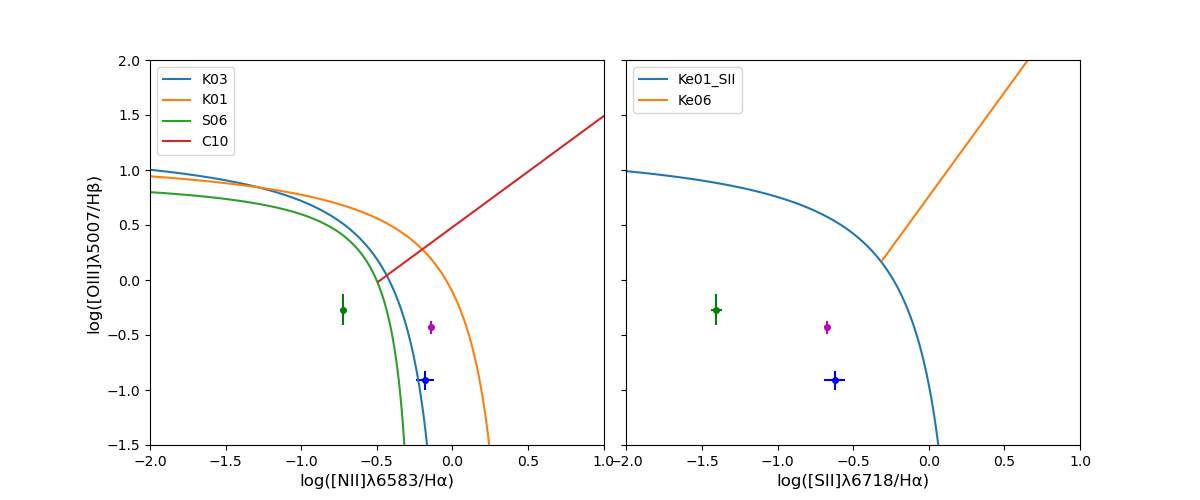

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both_true.png', bbox_inches='tight')

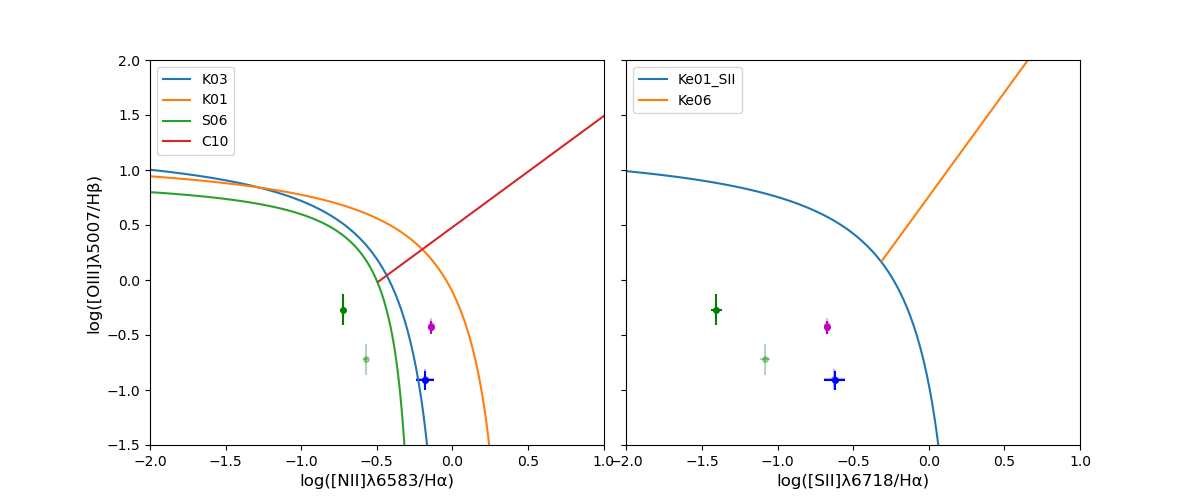

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_motion.png', bbox_inches='tight')